# Decomposition of FID into Sinusoidal Signals

The decomposition of an experimental FID into a superposition of sinusoidal signals
would deliver very useful information on frequencies, phases, amplitudes, and decay rates.
Such a list of parameters could then be compared with a database of expected signals, and
be used directly for quantification. This idea has been explored from the standpoint of
Bayesian probability theory by Bretthorst (https://www.sciencedirect.com/science/article/pii/002223649090287J}[J. Magn. Reson. 1990 ]), and applied by Krishnamurthy (https://onlinelibrary.wiley.com/doi/abs/10.1002/mrc.4022) to quantification, in combination with division of the FID into sub-FIDs corresponding 
to regions of interest in the spectrum.

Here, we explore the idea again and implement its basics in Julia.

In [1]:
versioninfo()

Julia Version 1.12.6
Commit 15346901f00 (2026-04-09 19:20 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: macOS (arm64-apple-darwin24.0.0)
  CPU: 12 × Apple M2 Max
  WORD_SIZE: 64
  LLVM: libLLVM-18.1.7 (ORCJIT, apple-m2)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 8 virtual cores)


In [2]:
import Pkg
Pkg.activate(".")

using Plots
using NMRflux
using JLD2
using LinearAlgebra
#  using LsqFit
using FFTW

# import DSP

theme(:solarized_light)
default(size=(600,400),
        tick_direction=:out,
        framestyle=:box,
        margin=(6,:mm),
        legendfontsize=8,
        guidefontsize=10,
        tickfontsize=10,
        fontfamily="Helvetica",
        fmt=:svg, dpi=100)

  Activating project at `~/2026-01-30`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [3]:
JLD2.@load "processedData.jld2"

2-element Vector{Symbol}:
 :processedData
 :fidData

## Digital Filtering of the FID

In many cases we are only interested in a limited frequency range of the spectrum.
This can be achieved by digital filtering before frequency estimation and fitting.

An ideal band-pass filter has a rectangular frequency response, which corresponds
in the time domain to a sinc function $h(t) = \sin(\pi B t)/(\pi t)$, where $B$
is the bandwidth. Because the FID is sampled and finite, this ideal filter must be
truncated to a finite impulse response (FIR) of length $2n+1$ samples.
Abrupt truncation introduces Gibbs ringing — large oscillatory artefacts near the
band edges — because the sharp cutoff in time creates spectral leakage in frequency.
Multiplying the truncated sinc by a **window function** tapers the coefficients
smoothly to zero at both ends, suppressing the sidelobes at the cost of a slightly
wider transition band.
The **Blackman window** $w(k) = 0.42 - 0.5\cos(\pi k/n) + 0.08\cos(2\pi k/n)$
is a particularly good choice here because it achieves very low sidelobe levels
(around -58 dB), which is important in NMR where weak peaks must be resolved
next to strong solvent or lipid signals.
Its three-term cosine form exactly cancels the first two sidelobe families of the
truncated sinc, trading a modestly wider passband for a clean stopband.
The band-reject filter is constructed as the complement of the band-pass
($\delta[t] - h_{\rm bp}(t)$), passing all frequencies except the rejected band.

## Frequency Estimation via ESPRIT

ESPRIT (Estimation of Signal Parameters via Rotational Invariance Techniques) is a
subspace method for estimating the frequencies of damped sinusoids in noise. It exploits
the algebraic structure of the signal subspace rather than searching over a frequency grid,
giving superresolution estimates that are not limited by the FFT bin spacing.

**Algorithm outline:**

1. **Hankel matrix.** From the FID $x[1],\ldots,x[N]$, form the $M \times L$ Hankel matrix
   ($L = \lfloor N/2 \rfloor$, $M = N - L + 1$):
   $$X_{ij} = x[i+j-1]$$
   For $K$ ideal damped sinusoids, $X$ has rank $K$ in the absence of noise.

2. **Signal subspace.** Compute the SVD of $X$. The $K$ dominant left singular vectors
   span the signal subspace $U_s$ ($M \times K$).

3. **Rotational invariance.** Split $U_s$ into two overlapping sub-matrices differing by
   one row:
   $$U_s^\uparrow = U_s[1{:}M-1,\,:\,], \qquad U_s^\downarrow = U_s[2{:}M,\,:\,]$$
   Because consecutive rows of $X$ are related by a time shift, these satisfy
   $U_s^\downarrow \approx U_s^\uparrow \Phi$, where $\Phi$ is a $K\times K$ matrix
   whose eigenvalues are $e^{(-\delta_k + i\omega_k)\Delta t}$.

4. **Frequency extraction.** Solve for $\Phi$ by least squares
   ($\Phi = (U_s^\uparrow)^+ U_s^\downarrow$) and take the angles of its eigenvalues
   to recover the frequencies $\omega_k$ in rad/sample.

**Reference:**
R. Roy and T. Kailath, "ESPRIT — Estimation of Signal Parameters via Rotational Invariance
Techniques," *IEEE Trans. Acoust., Speech, Signal Process.*, vol. 37, no. 7,
pp. 984–995, July 1989.

In [4]:
import NMRflux.Craft 

## Model Selection via Laplace Approximation to the Log Evidence

To compare models with different numbers of oscillators $K$, we need the
**model evidence** $p(\mathbf{x} \mid K)$ — the probability of the data after
marginalising over all parameter values:
$$p(\mathbf{x} \mid K) = \int p(\mathbf{x} \mid \mathbf{B}, K)\, p(\mathbf{B} \mid K)\, d\mathbf{B}$$
A model with more parameters fits better, but spreads its prior over a larger space,
incurring an automatic Occam penalty. The evidence balances fit quality against
model complexity without manual regularisation.

**Laplace approximation.** For a Gaussian likelihood with noise variance $\sigma^2$
and a broad, flat prior, expanding the log-posterior to second order around the
maximum-likelihood estimate $\hat{\mathbf{B}}$ gives:
$$\ln p(\mathbf{x} \mid K) \approx
  -\frac{n}{2}\ln\sigma^2
  +\frac{1}{2}\ln\det(J^\top J)
  -\frac{K}{2}\ln n$$
where $J$ is the Jacobian of the residuals evaluated at $\hat{\mathbf{B}}$,
$n$ is the number of data points, and $K$ is the number of fitted parameters.
The three terms are respectively the log-likelihood at the optimum, the log-volume
of the posterior peak (how well the data constrain the parameters), and the BIC
penalty for model complexity.

To select the number of oscillators, fit for $K = 1, 2, \ldots$ and choose the
$K$ with the highest log evidence.

**Numerical note.** When some parameters are poorly constrained (e.g. duplicate
frequencies), $J^\top J$ becomes singular. A small ridge $\varepsilon I$ is added
before taking the log-determinant to regularise this case.

## Signal Model

The FID is modelled as a superposition of $K$ damped complex sinusoids:
$$x(t) = \sum_{k=1}^{K} c_k \, e^{(-\delta_k + i\omega_k)t}$$
where $c_k = a_k e^{i\phi_k}$ is a complex amplitude encoding both the peak
amplitude $a_k$ and phase $\phi_k$, $\omega_k = 2\pi f_k$ is the angular
frequency, and $\delta_k > 0$ is the decay rate (inversely proportional to the
transverse relaxation time $T_2$).

**Why fix the frequencies?**
In principle one could fit all $4K$ parameters $(\text{Re}\,c_k,\,\text{Im}\,c_k,\,\omega_k,\,\delta_k)$
simultaneously. In practice this leads to a severely ill-conditioned optimisation
for two reasons.
First, the cost function has many nearly equivalent local minima: two oscillators
at slightly different frequencies can produce very similar residuals, so the
optimiser can swap, merge, or drift them without penalty.
Second, the Jacobian columns for $\omega_k$ and $\delta_k$ are proportional to
$c_k \cdot t \cdot e^{(-\delta_k+i\omega_k)t}$; if two oscillators converge to
the same frequency their columns become linearly dependent and the Jacobian
becomes singular.

ESPRIT provides accurate, superresolution frequency estimates directly from the
data, so there is no reason to re-estimate them by nonlinear optimisation.
Fixing $\omega_k$ at the ESPRIT values reduces the problem to $3K$ parameters
$( \text{Re}\,c_k,\,\text{Im}\,c_k,\,\delta_k )$.
For fixed frequencies the model is **linear** in the complex amplitudes $c_k$,
and only mildly nonlinear through the decay rates $\delta_k$, giving a
much better conditioned fit.

The decay rate is reparametrised as $\delta_k = \delta_{\max}\,\sigma(\gamma_k)$
where $\sigma$ is the sigmoid function, bounding $\delta_k$ strictly within
$(0, \delta_{\max})$ and preventing runaway decay during optimisation.

In [5]:
dt = step(NMRflux.coords(fidData,1))
SW = 1/dt
H2OReject = NMRflux.DigitalFilter(NMRflux.BandReject(-60.0/SW,250.0/SW,1000),1)
aromaticSelect = NMRflux.DigitalFilter(NMRflux.BandPass(-60.0/SW,250.0/SW,1000),1)

fidDataF = fidData |> H2OReject

35880×18 SpectData{ComplexF64, 2} with coords:(0.0:8.879999999999999e-5:3.1860551999999998, Any["yp-24h-5fu-1.jdf", "yp-24h-control-1.jdf", "yp-48h-5fu-1.jdf", "yp-48h-control-1.jdf", "yp-72h-5fu-1.jdf", "yp-72h-control-1.jdf", "yp-24h-5fu-2.jdf", "yp-24h-control-2.jdf", "yp-48h-5fu-2.jdf", "yp-48h-control-2.jdf", "yp-72h-5fu-2.jdf", "yp-72h-control-2.jdf", "yp-24h-5fu-3.jdf", "yp-24h-control-3.jdf", "yp-48h-5fu-3.jdf", "yp-48h-control-3.jdf", "yp-72h-5fu-3.jdf", "yp-72h-control-3.jdf"]):
  6.27158e-26+9.04229e-26im  …  -3.82222e-26+1.15941e-25im
 -3.72003e-15-6.02146e-15im      2.85005e-15-7.31653e-15im
  3.72678e-13+6.36719e-13im     -3.14144e-13+7.57451e-13im
 -1.79892e-11-2.40568e-11im      9.46328e-12-3.19065e-11im
 -1.14713e-10-1.38307e-10im      4.82899e-11-1.92323e-10im
 -3.15574e-10-3.5736e-10im   …   1.18175e-10-5.10843e-10im
 -6.60897e-10-7.28238e-10im      2.44281e-10-1.05448e-9im
  -1.12413e-9-1.23301e-9im       4.40159e-10-1.79289e-9im
  -1.68753e-9-1.89661e-9im       7.4

In [6]:
import NMRflux.Craft

δt = step(NMRflux.coords(fidDataF,1))
fid = fidDataF[1200:7200,1]
r = NMRflux.coords(fid,1)

freq_hz, decays, _  = Craft.esprit(fid , 180)
fit, result = Craft.fit_fid_fixed_freq(fid,freq_hz,decays)

(LsqFit.LsqFitResult{Vector{Float64}, Vector{Float64}, Matrix{Float64}, Vector{Float64}, Vector{LsqFit.LMState{LsqFit.LevenbergMarquardt}}}([0.977402819602852, 0.5496974887850714, -3.007681314194459, -0.0655246598127482, -0.13628170664579253, -3.3660369624467545, 0.24656848382285673, -0.08869110932641489, -3.6419865074971827, -0.1486183109944343  …  -2.526864729859432, 0.14585762629798246, 0.02361111769867141, -2.752501608570417, -0.06685741791643982, 0.11499700431491182, -2.906065992958733, 36.45935297401981, 81.09750002754853, 0.2042308336696704], [0.17582094791725678, -0.07933742050335679, -0.02782596879310706, 0.112837011491143, 0.16081536340198266, 0.16087108642617842, 0.1914802274095493, 0.261038135538497, 0.28392928783494753, 0.1780993930462138  …  -0.15273980121725983, -0.1360663586048767, -0.07888766619603604, -0.027486045879735244, 0.01807384277574542, 0.07346156601922949, 0.13282501901992383, 0.14063694725221465, 0.05449596650355715, -0.07973725322722985], [0.168390155484852

In [7]:
import JSON
open("fit_result.json", "w") do io
    JSON.print(io, result)
end


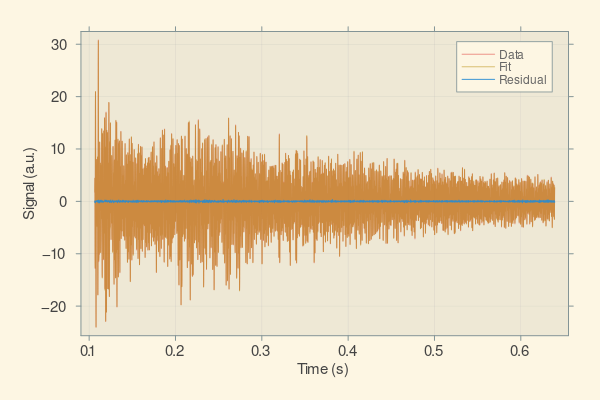

In [8]:
model_pred = Craft.oscillators_fixed_freq(r, fit.param, freq_hz)
plot(r, real(fid), label="Data",opacity=0.5,xlabel="Time (s)", ylabel="Signal (a.u.)") 
plot!(r, real(model_pred), label="Fit",opacity=0.5)
plot!(r, real(fid) - real(model_pred), label="Residual",opacity=0.9)

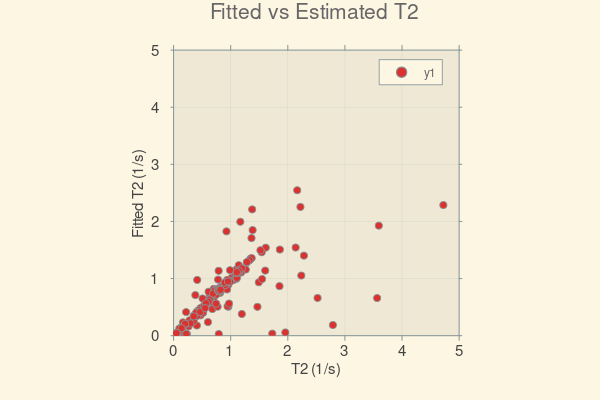

In [9]:
Plots.plot(pi ./ decays, pi ./ Craft.decay_rate_from_param.(fit.param[3:3:end]), seriestype=:scatter, xlabel="T2 (1/s)", ylabel="Fitted T2 (1/s)", title="Fitted vs Estimated T2",aspect_ratio=1,
xlims=(0,5),ylims=(0,5))

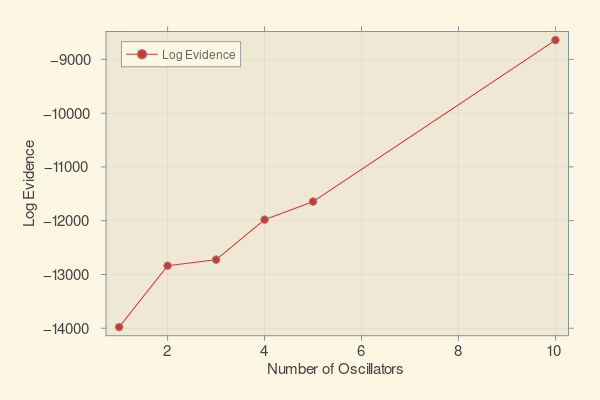

In [10]:
modelsizes=[1, 2, 3, 4, 5, 10] # , 20, 50, 100, 150, 200, 300, 500]
evidences = Float64[]
# modelsizes=[300,500]

for K in modelsizes
    freq_hz, decays,  _ = Craft.esprit(fid , K)
    fit, result = Craft.fit_fid_fixed_freq(fid,freq_hz,decays)
    push!(evidences, result["log_evidence"])
end

Plots.plot(modelsizes, evidences, marker=:o, label="Log Evidence", xlabel="Number of Oscillators", ylabel="Log Evidence")

In [11]:
K=150
freq_hz, decays,  _ = Craft.esprit(fid , K)
fit, result = Craft.fit_fid_fixed_freq(fid,freq_hz,decays)
Craft.resonance_table(result)

Row,frequency_hz,intensity,phase_rad,linewidth_hz
,Float64,Float64,Float64,Float64
1,-2866.49,1.12203,0.512311,0.941932
2,-2309.01,0.152553,-2.06528,0.671991
3,-2301.46,0.264532,-0.357905,0.514606
4,-2294.27,0.392451,1.94082,0.715983
5,-2287.88,0.525785,-1.84278,0.877125
6,-2281.23,0.271939,0.316223,0.809794
7,-2275.16,0.296157,-2.82548,0.519029
8,-2268.16,0.296124,-0.514061,0.510855
9,-2262.5,0.260106,2.57983,0.523894
